# RELATÓRIO TÉCNICO-CIENTÍFICO DE CALIBRAÇÃO EMPÍRICA
## Engenharia de Programa 2026.2 / Prof. Diego Frias
### Paradigma F.O.C.A. — 4.4. Custo de Coleção de Funções Opacas (F / τf)
**Responsável: Equipe (Opcional + 1 ponto extra)**

**Objetivo:** Executar a medição empírica direta, filtragem estatística de outliers por percentil (cortando 5% e 95%) e homologação dos custos de tempo (τf) para funções isoladas de biblioteca e nativas, garantindo a estabilidade (CV < 0.15).

**Justificativa dos Parâmetros:**
- **Tamanho da Amostra Interna (n = 500.000):** Diluir o custo de chamada do cronômetro (time.perf_counter) e garantir que a medição esteja acima da granularidade do sistema operacional.
- **Número de Repetições Globais (r = 40):** Garantir significância estatística para o cálculo de média, desvio padrão e aplicação do corte por percentil.

**Painel Gráfico de Estabilidade (Seção 3):** Exatamente 3 gráficos consolidados contendo todas as funções opacas sobrepostas por cores.

In [1]:
# ==============================================================================
# 1. SETUP DO AMBIENTE E VARIÁVEIS RESIDENTES
# ==============================================================================

import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Hiperparâmetros metodológicos
N = 500_000   # Tamanho da amostra interna (número de operações por repetição)
R = 40        # Número de repetições globais

# Setup de variáveis residentes em memória para evitar alocações dinâmicas
var_float = 1234.5678
var_int = -42
var_angle = 1.570796   # pi / 2
var_log = 100.0

# Warmup inicial do processador para estabilização de clock e cache
for _ in range(100_000):
    _ = math.sqrt(var_float)

print("Ambiente inicializado e aquecido com sucesso!")


Ambiente inicializado e aquecido com sucesso!


In [2]:
# ==============================================================================
# 2. MEDIÇÃO DIRETA IN-LINE (SEM FUNÇÕES INTERMEDIÁRIAS) DE TODAS AS FUNÇÕES
# ==============================================================================

tempos_brutos = {}
tempos_filtrados = {}
cortes_percentil = {}
tabela_resultados = []
reps = np.arange(1, R + 1)

def processar_estatisticas(nome_op, times_list):
    raw = np.array(times_list)
    tempos_brutos[nome_op] = raw
    
    mu_b = np.mean(raw)
    sigma_b = np.std(raw, ddof=1)
    cv_b = sigma_b / mu_b
    
    # Filtro de Percentil 5% e 95%
    p5 = np.percentile(raw, 5)
    p95 = np.percentile(raw, 95)
    cortes_percentil[nome_op] = (p5, p95)
    
    fil = raw[(raw >= p5) & (raw <= p95)]
    tempos_filtrados[nome_op] = fil
    
    mu_f = np.mean(fil)
    sigma_f = np.std(fil, ddof=1)
    cv_f = sigma_f / mu_f
    
    tabela_resultados.append({
        "Função (Biblioteca/Nativa)": nome_op,
        "µbruta (s)": f"{mu_b:.4e}",
        "σbruta (s)": f"{sigma_b:.4e}",
        "CVbruto": f"{cv_b:.4f}",
        "µfil(τf) (s)": f"{mu_f:.4e}",
        "σfil (s)": f"{sigma_f:.4e}",
        "CVfil": f"{cv_f:.4f}",
        "< 0.15": "Sim" if cv_f < 0.15 else "Não"
    })

print("Executando calibração de funções opacas (τf)...")

# 1. math.sqrt(var float)
t_f1 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        math.sqrt(var_float)
    t1 = time.perf_counter()
    t_f1.append((t1 - t0) / N)
processar_estatisticas("math.sqrt(var float)", t_f1)
print("  [1/4] Concluído: math.sqrt(var float)")

# 2. abs(var int)
t_f2 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        abs(var_int)
    t1 = time.perf_counter()
    t_f2.append((t1 - t0) / N)
processar_estatisticas("abs(var int)", t_f2)
print("  [2/4] Concluído: abs(var int)")

# 3. math.sin(var float)
t_f3 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        math.sin(var_angle)
    t1 = time.perf_counter()
    t_f3.append((t1 - t0) / N)
processar_estatisticas("[Função 1]: math.sin(var float)", t_f3)
print("  [3/4] Concluído: [Função 1]: math.sin(var float)")

# 4. math.log(var float)
t_f4 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        math.log(var_log)
    t1 = time.perf_counter()
    t_f4.append((t1 - t0) / N)
processar_estatisticas("[Função 2]: math.log(var float)", t_f4)
print("  [4/4] Concluído: [Função 2]: math.log(var float)")

print("\nTodas as 4 medições concluídas!")


Executando calibração de funções opacas (τf)...
  [1/4] Concluído: math.sqrt(var float)
  [2/4] Concluído: abs(var int)
  [3/4] Concluído: [Função 1]: math.sin(var float)
  [4/4] Concluído: [Função 2]: math.log(var float)

Todas as 4 medições concluídas!


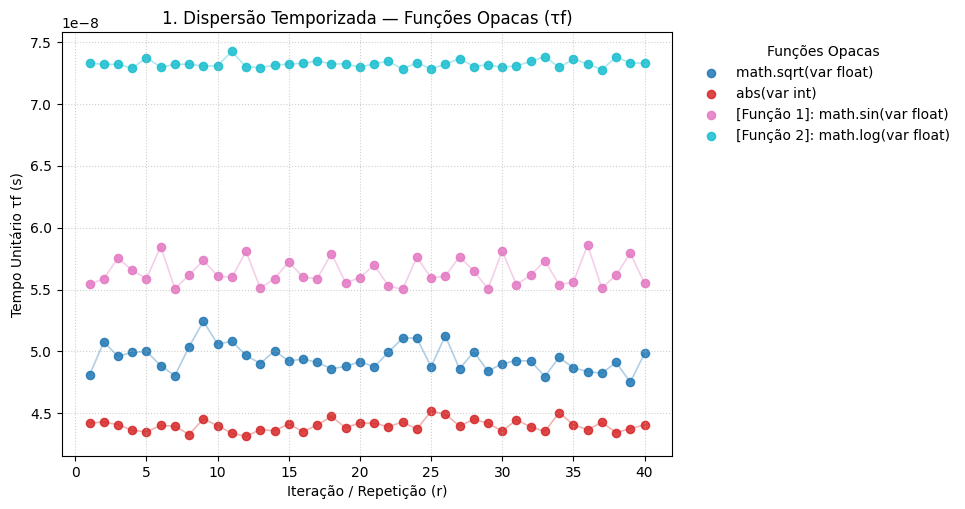

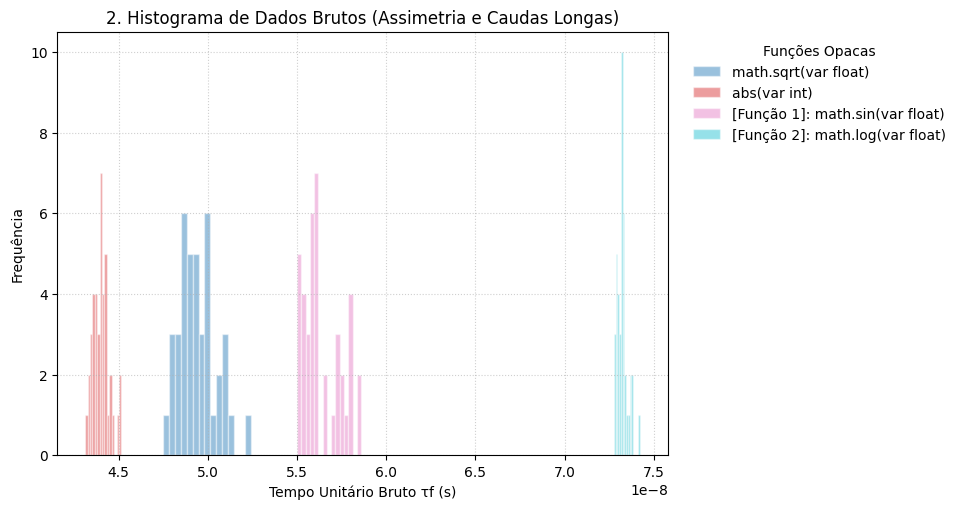

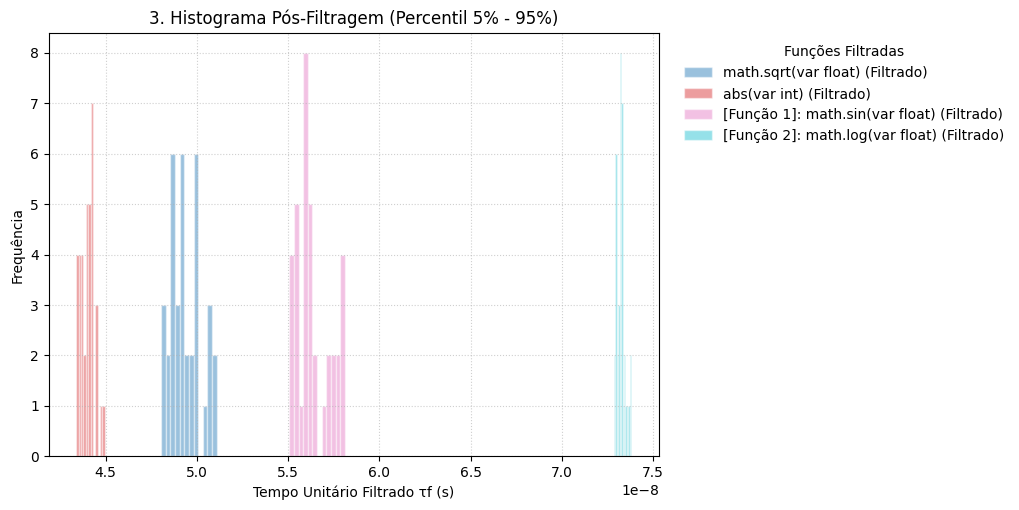

In [3]:
# ==============================================================================
# 3. PAINEL DE 3 GRÁFICOS CONSOLIDADOS (SEÇÃO 3 DO RELATÓRIO)
# ==============================================================================
# Exatamente 3 gráficos com todas as funções sobrepostas por cores

nomes_ops = list(tempos_brutos.keys())
cores_op = {nome: cor for nome, cor in zip(nomes_ops, plt.cm.tab10(np.linspace(0, 1, len(nomes_ops))))}

# ------------------------------------------------------------------------------
# 1) Gráfico de Dispersão Temporizada (r vs Tempo)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.scatter(reps, tempos_brutos[nome], color=cores_op[nome], label=nome, alpha=0.85, s=35)
    ax.plot(reps, tempos_brutos[nome], color=cores_op[nome], alpha=0.35, lw=1.2)

ax.set_xlabel("Iteração / Repetição (r)")
ax.set_ylabel("Tempo Unitário τf (s)")
ax.set_title("1. Dispersão Temporizada — Funções Opacas (τf)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Funções Opacas")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.68)
plt.show()

# ------------------------------------------------------------------------------
# 2) Histograma de Dados Brutos (Distribuição Sobreposta)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.hist(tempos_brutos[nome], bins=15, alpha=0.45, color=cores_op[nome], label=nome, edgecolor="white")

ax.set_xlabel("Tempo Unitário Bruto τf (s)")
ax.set_ylabel("Frequência")
ax.set_title("2. Histograma de Dados Brutos (Assimetria e Caudas Longas)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Funções Opacas")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.68)
plt.show()

# ------------------------------------------------------------------------------
# 3) Histograma Pós-Filtragem (Percentil 5% e 95%)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.hist(tempos_filtrados[nome], bins=12, alpha=0.45, color=cores_op[nome], label=f"{nome} (Filtrado)", edgecolor="white")

ax.set_xlabel("Tempo Unitário Filtrado τf (s)")
ax.set_ylabel("Frequência")
ax.set_title("3. Histograma Pós-Filtragem (Percentil 5% - 95%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Funções Filtradas")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.68)
plt.show()


In [4]:
# ==============================================================================
# 4. MATRIZ FINAL DE CALIBRAÇÃO HOMOLOGADA (τf) - TABELA 4.4
# ==============================================================================

# Configura o pandas para exibir todas as colunas sem quebra de linhas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

df_tau_f = pd.DataFrame(tabela_resultados)

print("\n" + "="*80)
print("4.4. CUSTO DE COLEÇÃO DE FUNÇÕES OPACAS (τf) - HOMOLOGAÇÃO (CV < 0.15)")
print("="*80)

# 1. Exibição garantida em texto plano (sem quebra)
print(df_tau_f.to_string(index=False))

# 2. Renderização interativa de tabela do Jupyter/VS Code
df_tau_f



4.4. CUSTO DE COLEÇÃO DE FUNÇÕES OPACAS (τf) - HOMOLOGAÇÃO (CV < 0.15)
     Função (Biblioteca/Nativa) µbruta (s) σbruta (s) CVbruto µfil(τf) (s)   σfil (s)  CVfil < 0.15
           math.sqrt(var float) 4.9428e-08 1.0506e-09  0.0213   4.9387e-08 8.4187e-10 0.0170    Sim
                   abs(var int) 4.4014e-08 4.7170e-10  0.0107   4.3998e-08 3.7626e-10 0.0086    Sim
[Função 1]: math.sin(var float) 5.6389e-08 1.0635e-09  0.0189   5.6345e-08 9.4373e-10 0.0167    Sim
[Função 2]: math.log(var float) 7.3240e-08 3.0981e-10  0.0042   7.3221e-08 2.3760e-10 0.0032    Sim


,Função (Biblioteca/Nativa),µbruta (s),σbruta (s),CVbruto,µfil(τf) (s),σfil (s),CVfil,< 0.15
0,math.sqrt(var float),4.9428e-08,1.0506e-09,0.0213,4.9387e-08,8.4187e-10,0.0170,Sim
1,abs(var int),4.4014e-08,4.7170e-10,0.0107,4.3998e-08,3.7626e-10,0.0086,Sim
2,[Função 1]: math.sin(var float),5.6389e-08,1.0635e-09,0.0189,5.6345e-08,9.4373e-10,0.0167,Sim
3,[Função 2]: math.log(var float),7.3240e-08,3.0981e-10,0.0042,7.3221e-08,2.3760e-10,0.0032,Sim


In [ ]:
# ==============================================================================
# 5. (OPCIONAL) PAINEL 1x3 PARA UMA FUNÇÃO ESPECÍFICA
# ==============================================================================

def plot_painel_individual(nome_op):
    raw = tempos_brutos[nome_op]
    fil = tempos_filtrados[nome_op]
    p5, p95 = cortes_percentil[nome_op]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    fig.suptitle(f"Painel Individual de Estabilidade — {nome_op}", fontsize=13, fontweight="bold")
    
    # 1. Dispersão Temporizada
    axes[0].scatter(reps, raw, color="#3B6BB5", s=35, alpha=0.85, edgecolor="white")
    axes[0].plot(reps, raw, color="#3B6BB5", alpha=0.35, lw=1.2)
    axes[0].set_xlabel("Iteração / Repetição (r)")
    axes[0].set_ylabel("Tempo Unitário τf (s)")
    axes[0].set_title("1. Dispersão Temporizada (Picos SO/GC)")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    
    # 2. Histograma de Dados Brutos
    axes[1].hist(raw, bins=12, color="#6B6B6B", edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("Tempo Bruto τf (s)")
    axes[1].set_ylabel("Frequência")
    axes[1].set_title("2. Histograma Bruto (Assimetria / Cauda Longa)")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    
    # 3. Histograma Pós-Filtragem
    axes[2].hist(fil, bins=10, color="#C1553B", edgecolor="white", alpha=0.8, label="Filtrado (5%-95%)")
    axes[2].axvline(p5, color="black", ls="--", lw=1.3, label=f"Corte P5% ({p5:.2e}s)")
    axes[2].axvline(p95, color="darkred", ls=":", lw=1.3, label=f"Corte P95% ({p95:.2e}s)")
    axes[2].set_xlabel("Tempo Filtrado τf (s)")
    axes[2].set_ylabel("Frequência")
    axes[2].set_title("3. Histograma Pós-Filtragem (Normalidade)")
    axes[2].legend(frameon=False, fontsize=9)
    axes[2].grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Exemplo de uso individual (descomente para usar):
# plot_painel_individual("math.sqrt(var float)")
